## Knowledge Graph (KG) + Graph Neural Network (GNN) Implementation for On-device Predictive Model

This approach is an alternative to the XGBoost + LSTM-based pipeline. Here, KG is utilized to map all the relationships between the various entities. For example:
  
A user ---uses--> a device.

These types of data mappings are very well suited for the given dataset.

### Dataset Used:
Samsung SmartThings Internet of Things (IoT) datasets. https://github.com/snudatalab/smartsense


## The main pipeline:
  
SmartThings Logs -> Data Preprocessing -> KG construction -> Graph Embedding / GNN Model -> Device Priority Prediction -> Ranked Device List


---
## Setup and Imports

In [ ]:
%pip install pandas matplotlib seaborn networkx scikit-learn tensorflow

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import tensorflow as tf


from src.evaluation.metrics import compute_ranking_metrics, mean_rank
from src.models.gnn_model import GCNEmbeddingLayer, ExpandFloatLayer
from src.training.train import ModelTrainer
from src.data.dataset_loader import DatasetLoader
from src.data.dictionary_manager import DictionaryManager
from src.graph.kg_builder import KGBuilder

from src.evaluation.visualization import (
    plot_confusion_matrix,
    plot_confusion_matrix_top_devices,
    per_device_classification_report,
    plot_metric_bars,
    print_classification_report,
    plot_top_predicted_devices,
    plot_per_device_f1,
)

from src.evaluation.latency import (
    benchmark_keras_inference,
    estimate_keras_model_size_mb,
)

from src.evaluation.analysis import (
    get_ranked_predictions,
    show_sample_ranking,
    compute_device_priority_stats,
    topk_coverage,
)



---
## Load the SmartThings Dataset

In [2]:
dictionary_manager = DictionaryManager(data_dir="data")

dataset_loader = DatasetLoader(
    dictionary_manager,
    data_dir="data"
)

(X_train, y_train), (X_val, y_val), (X_test, y_test), global_dict = dataset_loader.load_and_preprocess()

print("Train samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

INFO:src.data.dataset_loader:Building global dictionaries...
INFO:src.data.dataset_loader:Processing region: fr
INFO:src.data.dataset_loader:Processing region: kr
INFO:src.data.dataset_loader:Processing region: sp
INFO:src.data.dataset_loader:Processing region: us
INFO:src.data.dataset_loader:Total training instances: 261362


Train samples: 261362
Validation samples: 37340
Test samples: 74677


Here, each action is:

    [day_of_week, hour, device, control, device_control]

## Dataset Visualization

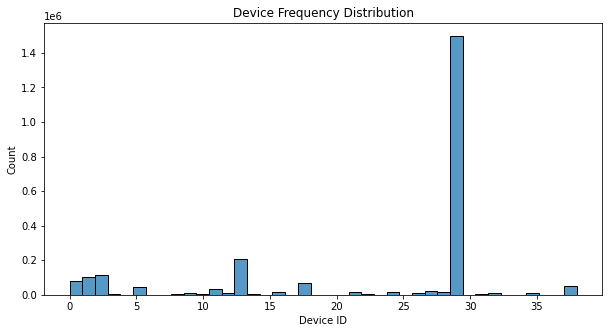

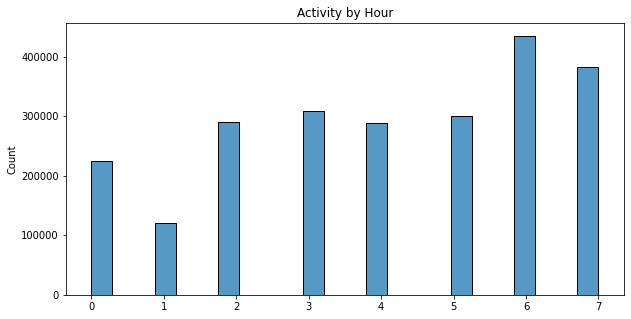

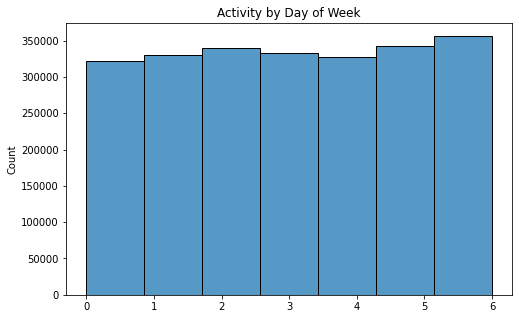

In [4]:
device_ids = X_train[:,:,2].flatten()
hours = X_train[:,:,1].flatten()
days = X_train[:,:,0].flatten()


plt.figure(figsize=(10,5))
sns.histplot(device_ids, bins=40)
plt.title("Device Frequency Distribution")
plt.xlabel("Device ID")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(hours, bins=24)
plt.title("Activity by Hour")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(days, bins=7)
plt.title("Activity by Day of Week")
plt.show()

## Build Knowledge Graph

In [5]:
kg_builder = KGBuilder(dictionary_manager, data_dir="data")
adj_matrix = kg_builder.build_adjacency_matrix()

print("Adjacency matrix shape:", adj_matrix.shape)
print("Min:", adj_matrix.min())
print("Max:", adj_matrix.max())
print("Nonzero entries:", (adj_matrix > 0).sum())
print("Diagonal sample:", adj_matrix.diagonal()[:10])

INFO:src.graph.kg_builder:Generated semantic device adjacency matrix with shape: (46, 46)


Adjacency matrix shape: (46, 46)
Min: 0.0
Max: 1.0
Nonzero entries: 316
Diagonal sample: [1.         0.66923714 0.6650876  0.6689032  0.6668047  0.726812
 0.86957747 0.8695651  0.6802647  0.6644136 ]


## Graph Visualization

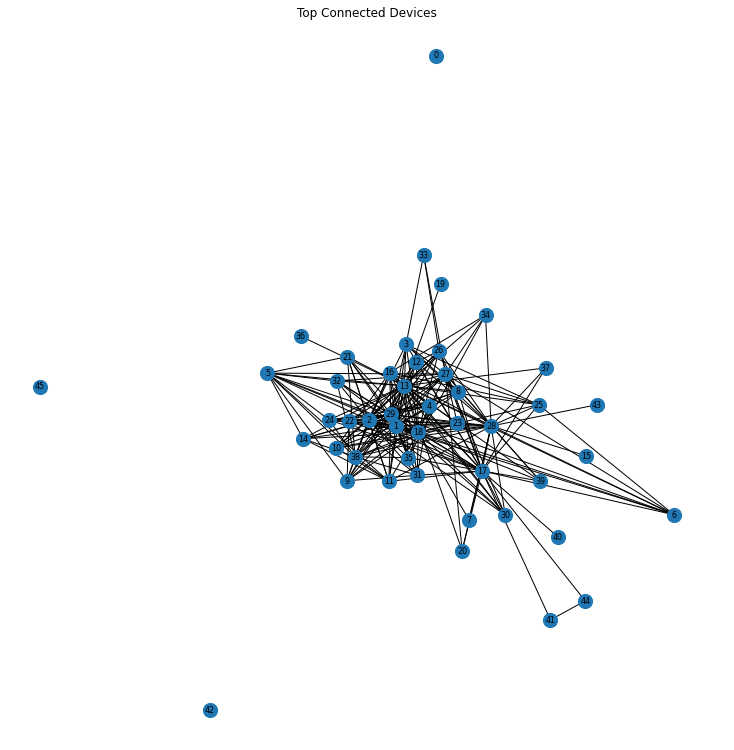

In [6]:
A_plot = adj_matrix.copy()
np.fill_diagonal(A_plot, 0)

G = nx.from_numpy_array(A_plot)

# Keep top 20 nodes by degree
degrees = dict(G.degree(weight="weight"))
# top_nodes = sorted(degrees, key=degrees.get, reverse=True)[:20]
top_nodes = sorted(degrees, key=degrees.get, reverse=True)
H = G.subgraph(top_nodes).copy()

plt.figure(figsize=(10, 10))
pos = nx.spring_layout(H, seed=42)
nx.draw(
    H,
    pos,
    node_size=200,
    with_labels=True,
    font_size=8
)
plt.title("Top Connected Devices")
plt.show()

## Build Keras Ranking Model

In [6]:
trainer = ModelTrainer(
    data_dir="data",
    model_dir="models"
)

results = trainer.train(
    epochs=10,
    batch_size=64
)

INFO:src.training.train:Loading and preprocessing datasets...
INFO:src.data.dataset_loader:Building global dictionaries...
INFO:src.data.dataset_loader:Processing region: fr
INFO:src.data.dataset_loader:Processing region: kr
INFO:src.data.dataset_loader:Processing region: sp
INFO:src.data.dataset_loader:Processing region: us
INFO:src.data.dataset_loader:Total training instances: 261362
INFO:src.training.train:Building semantic device adjacency...
INFO:src.graph.kg_builder:Generated semantic device adjacency matrix with shape: (46, 46)
INFO:src.training.train:Building predictive model...



INFO:src.training.train:Starting training...


Epoch 1/10
4079/4084 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7678 - loss: 0.9646
Epoch 1: val_loss improved from inf to 0.54687, saving model to models\best_gnn_model.keras
4084/4084 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step - accuracy: 0.7679 - loss: 0.9642 - val_accuracy: 0.8380 - val_loss: 0.5469
Epoch 2/10
4076/4084 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8371 - loss: 0.5528
Epoch 2: val_loss improved from 0.54687 to 0.51516, saving model to models\best_gnn_model.keras
4084/4084 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.8371 - loss: 0.5528 - val_accuracy: 0.8430 - val_loss: 0.5152
Epoch 3/10
4080/4084 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8407 - loss: 0.5251
Epoch 3: val_loss improved from 0.51516 to 0.50877, saving model to models\best_gnn_model.keras
4084/4084 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.8407 - loss: 0.5251 - val_accuracy: 0.8430 - val_loss: 0.5088
Epoch 4/10
4077/4084 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8410 - loss: 0.5164
Epoc

INFO:src.training.train:Evaluating on test set...
INFO:src.training.train:Test metrics: {'loss': 0.4884685277938843, 'compile_metrics': 0.8444501161575317}
INFO:src.training.train:Saving final .keras model...
INFO:src.training.train:Exporting SavedModel...
INFO:absl:Function `__call__` contains input name(s) resource, a with unsupported characters which will be renamed to smartthings_predictor_1_prediction_1_biasadd_readvariableop_resource, smartthings_predictor_1_gcn_device_embedding_1_matmul_a in the SavedModel.
INFO:absl:Function `__call__` contains input name(s) resource, a with unsupported characters which will be renamed to smartthings_predictor_1_prediction_1_biasadd_readvariableop_resource, smartthings_predictor_1_gcn_device_embedding_1_matmul_a in the SavedModel.


INFO:tensorflow:Assets written to: models\gnn_model\assets


INFO:tensorflow:Assets written to: models\gnn_model\assets


Saved artifact at 'models\gnn_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 9), dtype=tf.int32, name='dayofweek'), TensorSpec(shape=(None, 9), dtype=tf.int32, name='hour'), TensorSpec(shape=(None, 9), dtype=tf.int32, name='device'), TensorSpec(shape=(None, 9), dtype=tf.float32, name='unknown'), TensorSpec(shape=(None, 9), dtype=tf.int32, name='device_control')]
Output Type:
  TensorSpec(shape=(None, 46), dtype=tf.float32, name=None)
Captures:
  2313235158944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2313235159648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2313235168096: TensorSpec(shape=(46, 46), dtype=tf.float32, name=None)
  2313235167216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2313235161760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2313235162464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2313240635600: TensorSpec(shape=(), dtype=tf.resource, name=

INFO:src.training.train:Exported model to models\gnn_model


## Load Trained Model

In [7]:
model = tf.keras.models.load_model(
    "models/best_gnn_model.keras",
    custom_objects={
        "GCNEmbeddingLayer": GCNEmbeddingLayer,
        "ExpandFloatLayer": ExpandFloatLayer,
    },
    compile=False,
    safe_mode=False
)


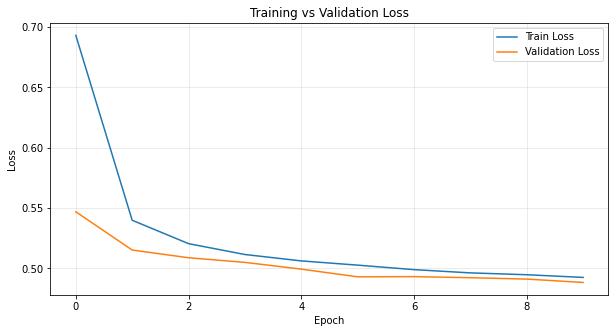

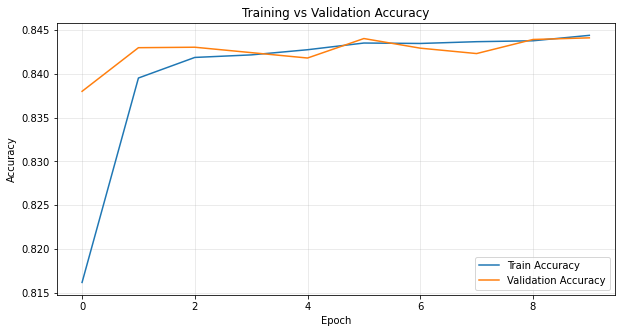

In [8]:
history = results["history"]

plt.figure(figsize=(10, 5))
plt.plot(history["loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

if "accuracy" in history and "val_accuracy" in history:
    plt.figure(figsize=(10, 5))
    plt.plot(history["accuracy"], label="Train Accuracy")
    plt.plot(history["val_accuracy"], label="Validation Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## Model Evaluation

In [9]:
def prepare_features(X):
    return {
        "dayofweek": X[:,:,0],
        "hour": X[:,:,1],
        "device": X[:,:,2],
        "unknown": X[:,:,3],
        "device_control": X[:,:,4]
    }

test_features = prepare_features(X_test)
pred_probs = model.predict(test_features)

2334/2334 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step


In [10]:
# Sample ranking
show_sample_ranking(
    model,
    X_test,
    prepare_features,
    sample_idx=0,
    top_k=10
)

# Device stats
df_stats = compute_device_priority_stats(
    model,
    X_test,
    y_test,
    prepare_features,
    top_k=5
)

df_stats.head()

Top-10 predictions for sample 0:
 1. device_13  score=0.9760
 2. device_29  score=0.0149
 3. device_18  score=0.0055
 4. device_0  score=0.0006
 5. device_16  score=0.0006
 6. device_11  score=0.0005
 7. device_1  score=0.0004
 8. device_26  score=0.0002
 9. device_5  score=0.0002
10. device_21  score=0.0002


,device_id,ground_truth_count,pred_top1_count,pred_topk_count,avg_pred_score,top1_bias_ratio,topk_bias_ratio
29,29,47441,50077,73999,0.634833,1.055563,1.559799
13,13,6429,6482,20114,0.085119,1.008243,3.128305
2,2,3508,3840,23591,0.046448,1.094614,6.723283
1,1,3470,2486,56125,0.044690,0.716508,16.169980
0,0,2503,2408,64297,0.036228,0.962061,25.678115


In [11]:
def evaluate_kg_gnn_model(model, X_test, y_test, model_name="KG_GNN Model"):
    features = prepare_features(X_test)
    y_prob = model.predict(features, verbose=0)

    ranking_metrics = compute_ranking_metrics(y_test, y_prob)
    latency_metrics = benchmark_keras_inference(
        model=model,
        sample_features={k: v[:1] for k, v in features.items()},
        num_warmup=20,
        num_runs=100,
    )
    coverage = topk_coverage(y_prob, top_k=5)
    rank_stats = float(mean_rank(y_test, y_prob))

    results = {
        "Model": model_name,
        **ranking_metrics,
        **latency_metrics,
        **coverage,
        rank_stats: rank_stats,
        "ModelSizeMB": estimate_keras_model_size_mb(model),
    }
    return results, y_prob

In [12]:
def print_kg_gnn_summary(results, title="KG_GNN MODEL BENCHMARKS"):
    print("=" * 80)
    print(title.center(80))
    print("=" * 80)
    print(f"{'Model':<22} {results['Model']}")
    print("-" * 80)
    print(f"{'MRR':<22} {results['MRR']:.4f}")
    print(f"{'Hit@1':<22} {results['Hit@1']:.4f}")
    print(f"{'NDCG@1':<22} {results['NDCG@1']:.4f}")
    print(f"{'Hit@3':<22} {results['Hit@3']:.4f}")
    print(f"{'NDCG@3':<22} {results['NDCG@3']:.4f}")
    print(f"{'Hit@5':<22} {results['Hit@5']:.4f}")
    print(f"{'NDCG@5':<22} {results['NDCG@5']:.4f}")
    print(f"{'Hit@10':<22} {results['Hit@10']:.4f}")
    print(f"{'NDCG@10':<22} {results['NDCG@10']:.4f}")
    print("-" * 80)
    print(f"{'Mean Rank':<22} {results['mean_rank']:.4f}")
    print(f"{'Median Rank':<22} {results['median_rank']:.4f}")
    print(f"{'Coverage Ratio':<22} {results['coverage_ratio']:.4f}")
    print(f"{'Unique Pred Devices':<22} {results['unique_predicted_devices']}")
    print(f"{'Total Devices':<22} {results['total_devices']}")
    print("-" * 80)
    print(f"{'Inference Mean (ms)':<22} {results['mean_ms']:.4f}")
    print(f"{'Inference P50 (ms)':<22} {results['p50_ms']:.4f}")
    print(f"{'Inference P95 (ms)':<22} {results['p95_ms']:.4f}")
    print(f"{'Inference P99 (ms)':<22} {results['p99_ms']:.4f}")
    print(f"{'Model Size (MB)':<22} {results['ModelSizeMB']:.4f}")
    print("=" * 80)

In [ ]:
results_kg_gnn, y_prob_kg_gnn = evaluate_kg_gnn_model(
    model,
    X_test,
    y_test,
    model_name="KG_GNN Model"
)

print_kg_gnn_summary(results_kg_gnn)

                            KG_GNN MODEL BENCHMARKS                             
Model                  KG_GNN Model
--------------------------------------------------------------------------------
MRR                    0.9079
Hit@1                  0.8445
NDCG@1                 0.8445
Hit@3                  0.9684
NDCG@3                 0.9199
Hit@5                  0.9812
NDCG@5                 0.9252
Hit@10                 0.9915
NDCG@10                0.9286
--------------------------------------------------------------------------------
Mean Rank              1.3815
Median Rank            1.0000
Coverage Ratio         0.5652
Unique Pred Devices    26
Total Devices          46
--------------------------------------------------------------------------------
Inference Mean (ms)    29.8309
Inference P50 (ms)     28.6413
Inference P95 (ms)     37.6926
Inference P99 (ms)     46.5240
Model Size (MB)        0.1106


===== KG-GNN MODEL EVALUATION =====

--- Ranking Metrics ---
MRR            : 0.9079
Hit@1          : 0.8445
NDCG@1         : 0.8445
Hit@3          : 0.9684
NDCG@3         : 0.9199
Hit@5          : 0.9812
NDCG@5         : 0.9252
Hit@10         : 0.9915
NDCG@10        : 0.9286
mean_rank      : 1.3815
median_rank    : 1.0000
coverage_ratio : 0.9915

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.76      0.73      0.74      2503
           1       0.73      0.52      0.61      3470
           2       0.70      0.76      0.73      3508
           3       0.55      0.39      0.45       145
           4       0.54      0.14      0.23        49
           5       0.72      0.79      0.76      1431
           8       0.83      0.18      0.29        56
           9       0.47      0.24      0.32       338
          10       0.48      0.36      0.41        95
          11       0.73      0.60      0.66      1043
          12       0.79  

<Figure size 720x576 with 0 Axes>

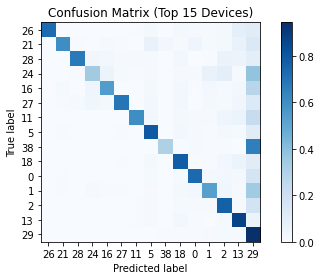


--- Metric Visualization ---


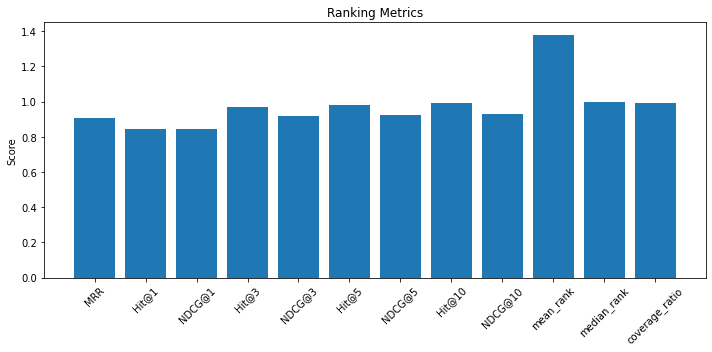


--- Per-Device Analysis ---


,precision,recall,f1,support,device_id
0,0.756645,0.727926,0.742008,2503.0,0
1,0.729686,0.522767,0.609134,3470.0,1
2,0.696354,0.762258,0.727817,3508.0,2
3,0.549020,0.386207,0.453441,145.0,3
4,0.538462,0.142857,0.225806,49.0,4


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


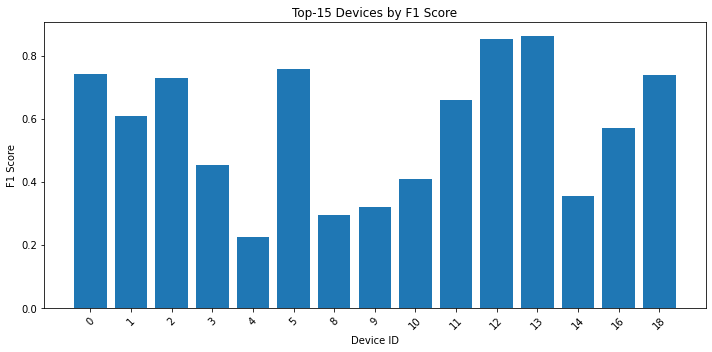


--- Device Priority Stats ---


,device_id,ground_truth_count,pred_top1_count,pred_topk_count,avg_pred_score,top1_bias_ratio,topk_bias_ratio
29,29,47441,50077,73999,0.634833,1.055563,1.559799
13,13,6429,6482,20114,0.085119,1.008243,3.128305
2,2,3508,3840,23591,0.046448,1.094614,6.723283
1,1,3470,2486,56125,0.044690,0.716508,16.169980
0,0,2503,2408,64297,0.036228,0.962061,25.678115


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


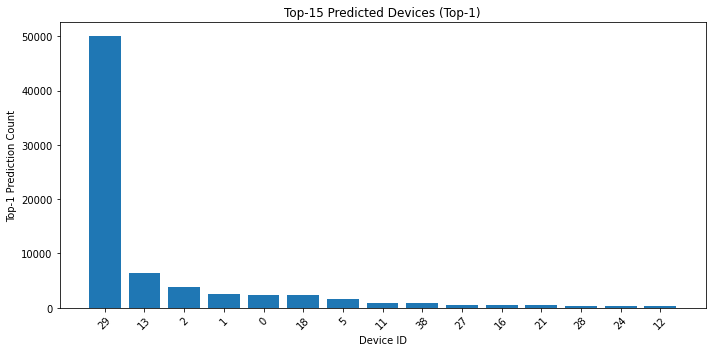


--- Coverage Analysis ---
unique_predicted_devices : 26
total_devices            : 46
coverage_ratio           : 0.5652173913043478

--- Sample Prediction (Debug View) ---
Top-10 predictions for sample 0:
 1. device_13  score=0.9760
 2. device_29  score=0.0149
 3. device_18  score=0.0055
 4. device_0  score=0.0006
 5. device_16  score=0.0006
 6. device_11  score=0.0005
 7. device_1  score=0.0004
 8. device_26  score=0.0002
 9. device_5  score=0.0002
10. device_21  score=0.0002

--- Performance (Latency & Size) ---
Latency Stats:
mean_ms        : 554.7514
std_ms         : 33.6060
p50_ms         : 550.9190
p90_ms         : 598.1435
p95_ms         : 618.9520
p99_ms         : 661.0071

Model Size (MB): 0.11

===== EVALUATION COMPLETE =====


In [ ]:
# ================================

# KG-GNN MODEL: FULL EVALUATION

# ================================

print("===== KG-GNN MODEL EVALUATION =====")

# ---- 1. Predictions ----

test_features = prepare_features(X_test)
y_prob = model.predict(test_features, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

# ---- 2. Ranking Metrics ----

print("\n--- Ranking Metrics ---")
metrics = compute_ranking_metrics(y_test, y_prob)

for k, v in metrics.items():
    print(f"{k:15s}: {v:.4f}")

# ---- 3. Classification Report ----

print("\n--- Classification Report ---")
print_classification_report(y_test, y_pred)

# ---- 4. Confusion Matrices ----

# print("\n--- Confusion Matrix ---")
# plot_confusion_matrix(y_test, y_pred)

print("\n--- Confusion Matrix (Top Devices) ---")
plot_confusion_matrix_top_devices(y_test, y_pred, top_n=15)

# ---- 5. Metric Visualization ----

print("\n--- Metric Visualization ---")
plot_metric_bars(metrics)

# ---- 6. Per-Device Analysis ----

print("\n--- Per-Device Analysis ---")

df_report = per_device_classification_report(y_test, y_pred)
display(df_report.head())

plot_per_device_f1(df_report, top_n=15)

# ---- 7. Device Priority / Bias Analysis ----

print("\n--- Device Priority Stats ---")

df_stats = compute_device_priority_stats(
model,
X_test,
y_test,
prepare_features,
top_k=5
)

display(df_stats.head())

plot_top_predicted_devices(df_stats, top_n=15)

# ---- 8. Coverage Analysis ----

print("\n--- Coverage Analysis ---")

coverage_stats = topk_coverage(
y_prob,
top_k=5
)

for k, v in coverage_stats.items():
    print(f"{k:25s}: {v}")

# ---- 9. Sample Prediction Inspection ----

print("\n--- Sample Prediction (Debug View) ---")

show_sample_ranking(
model,
X_test,
prepare_features,
sample_idx=0,
top_k=10
)

# ---- 10. Latency + Model Size ----

print("\n--- Performance (Latency & Size) ---")

latency_stats = benchmark_keras_inference(
model,
test_features,
num_runs=100
)

model_size = estimate_keras_model_size_mb(model)

print("Latency Stats:")
for k, v in latency_stats.items():
    print(f"{k:15s}: {v:.4f}")

print(f"\nModel Size (MB): {model_size:.2f}")

print("\n===== EVALUATION COMPLETE =====")


# TFLite Model Testing

Here we test how well the converted TFlite model performs with comparisons to the regular keras model and also specific tests on the converted model

In [3]:
from src.evaluation.mobile_tester import (
    compare_models, 
    evaluate_tflite,
    evaluate_topk_tflite,
    benchmark,
    cosine_similarity_models,
)

KERAS_MODEL_PATH = "models/best_gnn_model.keras"
TFLITE_MODEL_PATH = "models/gnn_model.tflite"


def extract_sample(X, i):
    return {
        "dayofweek": X[i:i+1, :, 0].astype(np.float32), 
        "hour": X[i:i+1, :, 1].astype(np.float32),      
        "device": X[i:i+1, :, 2].astype(np.float32),     
        "unknown": X[i:i+1, :, 3].astype(np.float32),
        "device_control": X[i:i+1, :, 4].astype(np.float32),  
    }


sample = extract_sample(X_test, 0)

interpreter = tf.lite.Interpreter(model_path="models/gnn_model.tflite")
interpreter.allocate_tensors()

keras_model = tf.keras.models.load_model(
    KERAS_MODEL_PATH,
    custom_objects={
        "GCNEmbeddingLayer": GCNEmbeddingLayer,
        "ExpandFloatLayer": ExpandFloatLayer
    }
)

compare_models(keras_model, TFLITE_MODEL_PATH, sample)
evaluate_tflite(interpreter, X_test, y_test)
evaluate_topk_tflite(interpreter, X_test, y_test)
benchmark(interpreter, sample, runs=100)
cosine_similarity_models(keras_model, TFLITE_MODEL_PATH, X_test, 100)



Mean absolute difference: 0.00017497496
Accuracy: 0.8493779878677504
Top-3 Accuracy: 0.9697
Top-5 Accuracy: 0.9820
Avg latency (ms): 0.16145706176757812
Average Cosine Similarity: 0.977549


0.97754866